# Multi-Task v1 — Shared Encoder, Three Heads (Seg + Keypoint + Cobb)

Sibling of `model_primer_v3_corrected`. Same ResNet-34 + U-Net backbone on the **corrected v2** dataset (249 trainable / 178 with Cobb GT), but with three supervision signals coming out of the same encoder:

1. **Seg head** — 18-class multiclass mask (bg + T1..L5)
2. **Keypoint head** — 68 Gaussian heatmaps (17 vertebrae × 4 corners)
3. **Cobb head** — direct scalar regression of the spinal angle

Target: match or beat `model_primer_v3_corrected` baseline (~0.64 mean val dice) while gaining keypoint and direct Cobb predictions for the same training cost.

Single 80/20 split (no k-fold) — k-fold reserved for follow-up notebook once the loss balance is calibrated.

Architecture defined inline in this notebook (sandbox tier — promotion path is sandbox → experiments → final → `ai/models/architectures/`).

## 0 · Setup

In [1]:
import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from torch.utils.data import DataLoader, Dataset
from torchvision import models

warnings.filterwarnings("ignore", message=".*lerp.*")

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found above CWD")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PARAMS = yaml.safe_load((REPO_ROOT / "params.yaml").read_text())
SEED = int(PARAMS["data"]["random_seed"])

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    try:
        import torch_directml
        DEVICE = torch_directml.device()
    except ImportError:
        DEVICE = torch.device("cpu")
print(f"repo={REPO_ROOT}\ndevice={DEVICE}\nseed={SEED}")

repo=/home/ortiz/scoliosis
device=privateuseone:0
seed=42


In [3]:
from ai.evaluation.cobb import cobb_from_segmentation_tangent
from ai.preprocessing.keypoints import (
    KEYPOINTS_PER_VERTEBRA,
    TOTAL_KEYPOINTS,
    multiclass_mask_to_keypoints,
)
from ai.preprocessing.segmentation import NUM_SEG_CLASSES
from ai.training.augmentation import augment_v4
from ai.training.dataset import (
    IMG_H,
    IMG_W,
    TARGET_IDS_V2,
    preprocess_case,
)
from ai.training.losses import seg_loss_fn

NUM_VERT = len(TARGET_IDS_V2)
print(f"size={IMG_H}x{IMG_W}  seg_classes={NUM_SEG_CLASSES}  vertebrae={NUM_VERT}  keypoints={TOTAL_KEYPOINTS}")

size=512x256  seg_classes=18  vertebrae=17  keypoints=68


In [4]:
CLEAN_INDEX_CSV = REPO_ROOT / "data" / "processed" / "audit_v2_corrected" / "clean_index.csv"

def load_clean_index(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"{path} missing — run audit generation first")
    return pd.read_csv(path)

def trainable_rows(df: pd.DataFrame, min_vertebrae: int = 14) -> pd.DataFrame:
    mask = df["status"].isin(["ok", "warn"])
    if "target_vertebrae_count" in df.columns:
        mask = mask & (df["target_vertebrae_count"] >= min_vertebrae)
    return df[mask].reset_index(drop=True)

def split_train_val(df: pd.DataFrame, val_frac: float = 0.2, seed: int = SEED) -> tuple[pd.DataFrame, pd.DataFrame]:
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_val = max(1, int(round(len(shuffled) * val_frac)))
    return shuffled.iloc[n_val:].reset_index(drop=True), shuffled.iloc[:n_val].reset_index(drop=True)

CLEAN_INDEX = load_clean_index(CLEAN_INDEX_CSV)
TRAINABLE = trainable_rows(CLEAN_INDEX)
TRAIN_DF, VAL_DF = split_train_val(TRAINABLE, val_frac=0.2, seed=SEED)
n_with_cobb = TRAINABLE["cobb_angle_deg"].notna().sum()
print(f"total={len(CLEAN_INDEX)}  trainable={len(TRAINABLE)} (cobb_gt={n_with_cobb})  train={len(TRAIN_DF)}  val={len(VAL_DF)}")

total=250  trainable=249 (cobb_gt=178)  train=199  val=50


## 1 · I/O Contract — Three Targets per Sample

| Tensor | Shape | Dtype | Source | Notes |
|---|---|---|---|---|
| `image` | `(1, 512, 256)` | float32 | grayscale X-ray, normalized to `[0, 1]` | |
| `seg` | `(512, 256)` | int64 | per-pixel class `0..17` | |
| `kpt_heatmap` | `(68, 128, 64)` | float32 | Gaussian blob per corner at H/4 × W/4 | zeros where vertebra missing |
| `kpt_valid` | `(68,)` | bool | mask of finite keypoints | warn cases (14–16 vert) have ≤16 valid groups |
| `cobb` | `()` | float32 | scalar Cobb angle (degrees) | NaN when missing |
| `cobb_valid` | `()` | bool | True if `cobb` is finite | only ~178 / 249 cases |

Heatmaps live at H/4 × W/4 (= 128 × 64) to keep the keypoint output tensor under 10 MB per sample. Argmax + ×4 scaling recovers pixel coordinates.

In [5]:
HEATMAP_DOWNSAMPLE = 4
HM_H = IMG_H // HEATMAP_DOWNSAMPLE  # 128
HM_W = IMG_W // HEATMAP_DOWNSAMPLE  # 64
HEATMAP_SIGMA = 2.0  # gaussian sigma in heatmap-resolution pixels

def render_heatmaps(
    keypoints_xy_full: np.ndarray,
    h: int = HM_H,
    w: int = HM_W,
    downsample: int = HEATMAP_DOWNSAMPLE,
    sigma: float = HEATMAP_SIGMA,
) -> tuple[np.ndarray, np.ndarray]:
    """Return (heatmaps (K,h,w) float32, valid (K,) bool)."""
    k = keypoints_xy_full.shape[0]
    hm = np.zeros((k, h, w), dtype=np.float32)
    valid = np.zeros((k,), dtype=bool)
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    for i in range(k):
        x_full, y_full = keypoints_xy_full[i]
        if not (np.isfinite(x_full) and np.isfinite(y_full)):
            continue
        cx = x_full / downsample
        cy = y_full / downsample
        hm[i] = np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2.0 * sigma ** 2))
        valid[i] = True
    return hm, valid


def keypoints_from_heatmaps(
    hm: torch.Tensor,
    threshold: float = 0.1,
    upsample: int = HEATMAP_DOWNSAMPLE,
) -> tuple[np.ndarray, np.ndarray]:
    """Argmax peak per channel, scale to full-resolution pixel coords.

    Args:
        hm: (K, h, w) heatmap tensor
    Returns:
        coords: (K, 2) float array of (x, y) in full-resolution pixels (NaN if peak < threshold)
        scores: (K,) peak intensities
    """
    k, h, w = hm.shape
    flat = hm.reshape(k, -1)
    scores, idx = flat.max(dim=1)
    ys = (idx // w).float() * upsample
    xs = (idx % w).float() * upsample
    coords = torch.stack([xs, ys], dim=1).cpu().numpy()
    s = scores.cpu().numpy()
    coords[s < threshold] = np.nan
    return coords, s

In [6]:
sample = TRAINABLE.iloc[0]
case = preprocess_case(sample)
kps_full = case["kps"].numpy()
hm, valid = render_heatmaps(kps_full)
cobb = sample.get("cobb_angle_deg")
print(f"image          {tuple(case['image'].shape)} {case['image'].dtype}")
print(f"seg            {tuple(case['seg'].shape)} {case['seg'].dtype}  classes={sorted(torch.unique(case['seg']).tolist())[:6]}...")
print(f"kps (full px)  {kps_full.shape} finite={int(np.isfinite(kps_full).all(axis=1).sum())}/{TOTAL_KEYPOINTS}")
print(f"heatmaps       {hm.shape}  valid={int(valid.sum())}/{TOTAL_KEYPOINTS}  peak={hm.max():.3f}")
print(f"cobb           {cobb}")

image          (1, 512, 256) torch.float32
seg            (512, 256) torch.int64  classes=[0, 1, 2, 3, 4, 5]...
kps (full px)  (68, 2) finite=68/68
heatmaps       (68, 128, 64)  valid=68/68  peak=0.999
cobb           nan


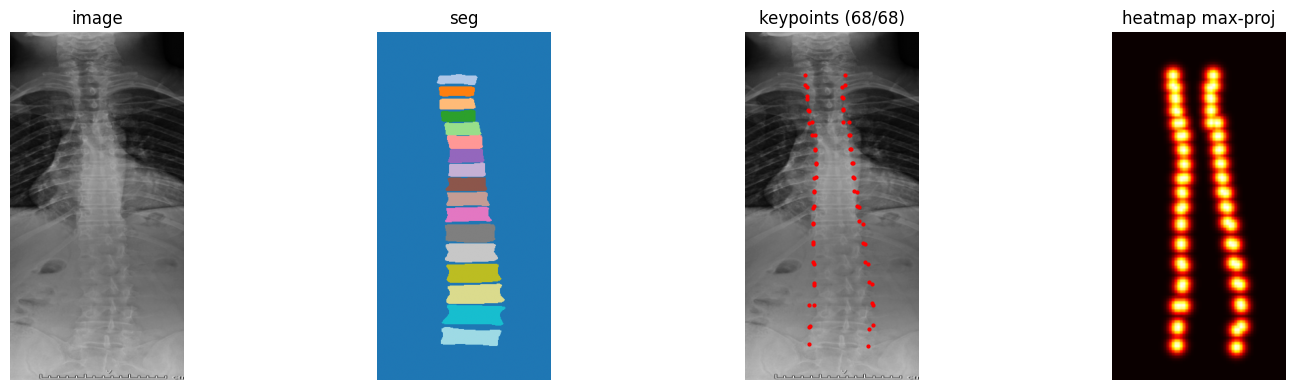

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("image")
axes[1].imshow(case["seg"], cmap="tab20"); axes[1].set_title("seg")
# overlay first 4 keypoints (corners of T1) on image
axes[2].imshow(case["image"].squeeze(0), cmap="gray")
fin = np.isfinite(kps_full).all(axis=1)
axes[2].scatter(kps_full[fin, 0], kps_full[fin, 1], s=4, c="red")
axes[2].set_title(f"keypoints ({int(fin.sum())}/68)")
# combined heatmap (max-projection over channels)
axes[3].imshow(hm.max(axis=0), cmap="hot"); axes[3].set_title("heatmap max-proj")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 2 · Multi-Task Dataset

Wraps `preprocess_case` and adds heatmap rendering + Cobb extraction. Augmentation reuses `augment_v4` on `(image, seg)`, then **re-extracts keypoints from the augmented seg** so they always agree spatially. Cobb GT is invariant under spatial augmentation only when no horizontal flip occurred — we mask Cobb when flips fire (cheaper than computing post-flip ground-truth).

In [8]:
class MultiTaskSpineDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        augment: bool = False,
        target_ids: tuple[int, ...] = TARGET_IDS_V2,
    ):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.target_ids = target_ids

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, i: int) -> dict[str, torch.Tensor]:
        row = self.df.iloc[i]
        case = preprocess_case(row, target_ids=self.target_ids)
        image, seg = case["image"], case["seg"]

        flipped = False
        if self.augment:
            # apply the same augment chain as v3, but track horizontal flip
            # so we can mask the Cobb target (cheap; flip preserves seg/kpt geometrically)
            pre_left = float(image[:, :, : image.shape[-1] // 2].sum())
            image, seg = augment_v4(image, seg)
            post_left = float(image[:, :, : image.shape[-1] // 2].sum())
            # heuristic: if the left/right energy swapped sign, a flip happened
            flipped = abs(post_left - pre_left) > 0.5 * abs(pre_left)  # coarse but adequate

        # re-extract keypoints from (possibly augmented) seg so they spatially agree
        seg_np = seg.numpy().astype(np.uint8)
        # remapped label space already matches target_ids index → recover raw vertebra IDs
        # by indexing back: 0=bg, 1..17 → target_ids[0..16]
        # multiclass_mask_to_keypoints expects raw IDs, so we rebuild a raw-id mask:
        raw = np.zeros_like(seg_np)
        for k_idx, raw_id in enumerate(self.target_ids, start=1):
            raw[seg_np == k_idx] = raw_id
        kps_full = multiclass_mask_to_keypoints(raw, target_ids=self.target_ids)
        hm, valid = render_heatmaps(kps_full)

        cobb_val = row.get("cobb_angle_deg")
        if pd.isna(cobb_val) or flipped:
            cobb_t = torch.tensor(0.0, dtype=torch.float32)
            cobb_valid = torch.tensor(False)
        else:
            cobb_t = torch.tensor(float(cobb_val), dtype=torch.float32)
            cobb_valid = torch.tensor(True)

        return {
            "image": image,
            "seg": seg,
            "kpt_heatmap": torch.from_numpy(hm),
            "kpt_valid": torch.from_numpy(valid),
            "cobb": cobb_t,
            "cobb_valid": cobb_valid,
        }


def multitask_collate(batch: list[dict]) -> dict[str, torch.Tensor]:
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0]}


# sanity check one batch
_ds = MultiTaskSpineDataset(TRAIN_DF.head(4), augment=False)
_b = multitask_collate([_ds[i] for i in range(4)])
for k, v in _b.items():
    print(f"  {k:14s}  {tuple(v.shape)}  {v.dtype}")

  image           (4, 1, 512, 256)  torch.float32
  seg             (4, 512, 256)  torch.int64
  kpt_heatmap     (4, 68, 128, 64)  torch.float32
  kpt_valid       (4, 68)  torch.bool
  cobb            (4,)  torch.float32
  cobb_valid      (4,)  torch.bool


## 3 · MultiTask Architecture

ResNet-34 encoder (ImageNet-pretrained, grayscale stem) shared across three heads:

- **Seg head**  — 1×1 conv on full-resolution decoder features → 18 logits per pixel (identical to `EncoderUNet`)
- **Kpt head**  — 1×1 conv on H/4 decoder features → 68 heatmaps (matches dataset target resolution, no extra upsample)
- **Cobb head** — global average pool on the bottleneck (B, 512, H/32, W/32) → 2-layer MLP → scalar (degrees)

Encoder/decoder topology mirrors `ai/models/architectures/encoder_unet.py`. Decoder features are tapped at two resolutions (H/4 for keypoints, H for seg).

In [9]:
def _conv_block(in_ch: int, out_ch: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class _Up(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = _conv_block(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        dy = skip.shape[2] - x.shape[2]
        dx = skip.shape[3] - x.shape[3]
        if dy != 0 or dx != 0:
            x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        return self.conv(torch.cat([x, skip], dim=1))


class MultiTaskEncoderUNet(nn.Module):
    """Shared ResNet-34 encoder with seg + keypoint + Cobb heads."""

    def __init__(
        self,
        in_ch: int = 1,
        num_seg_classes: int = NUM_SEG_CLASSES,
        num_keypoints: int = TOTAL_KEYPOINTS,
        pretrained: bool = True,
        dropout: float = 0.2,
        cobb_norm: float = 90.0,
    ):
        super().__init__()
        self.cobb_norm = cobb_norm

        weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet34(weights=weights)

        original_conv1 = backbone.conv1
        self.conv1 = nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained and in_ch == 1:
            self.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)
        elif pretrained and in_ch == 3:
            self.conv1.weight.data = original_conv1.weight.data

        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.up1 = _Up(512, 256, 256)
        self.up2 = _Up(256, 128, 128)
        self.up3 = _Up(128, 64, 64)   # produces (B, 64, H/4, W/4) — keypoint tap
        self.up4 = _Up(64, 64, 64)    # produces (B, 64, H/2, W/2)
        self.final_up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.drop = nn.Dropout2d(dropout)

        # heads
        self.seg_head = nn.Conv2d(64, num_seg_classes, 1)
        self.kpt_head = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_keypoints, 1),
        )
        self.cobb_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

        self._encoder_modules = [
            self.conv1, self.bn1, self.layer1, self.layer2, self.layer3, self.layer4,
        ]
        self._decoder_modules = [
            self.up1, self.up2, self.up3, self.up4, self.final_up, self.drop,
            self.seg_head, self.kpt_head, self.cobb_head,
        ]

    def forward(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        x0 = self.relu(self.bn1(self.conv1(x)))
        x_pool = self.maxpool(x0)
        s1 = self.layer1(x_pool)
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)
        bridge = self.layer4(s3)  # (B, 512, H/32, W/32) — Cobb tap

        y = self.up1(bridge, s3)
        y = self.up2(y, s2)
        y_q = self.up3(y, s1)              # (B, 64, H/4, W/4) — kpt tap
        y = self.up4(y_q, x0)
        y_full = self.final_up(y)          # (B, 64, H, W)
        y_full = self.drop(y_full)

        seg_logits = self.seg_head(y_full)
        kpt_heatmaps = self.kpt_head(y_q)  # (B, 68, H/4, W/4)
        cobb_norm_pred = self.cobb_head(bridge).squeeze(-1)  # (B,)
        cobb_pred = cobb_norm_pred * self.cobb_norm  # rescale to degrees

        return {
            "seg": seg_logits,
            "kpt": kpt_heatmaps,
            "cobb": cobb_pred,
        }

    def encoder_params(self):
        for m in self._encoder_modules:
            yield from m.parameters()

    def decoder_params(self):
        for m in self._decoder_modules:
            yield from m.parameters()


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


model = MultiTaskEncoderUNet(pretrained=True, dropout=0.2).to(DEVICE)
n_enc = sum(p.numel() for p in model.encoder_params())
n_dec = sum(p.numel() for p in model.decoder_params())
print(f"MultiTaskEncoderUNet total params: {count_params(model):,}")
print(f"  encoder: {n_enc:,}  decoder+heads: {n_dec:,}")

MultiTaskEncoderUNet total params: 24,501,303
  encoder: 21,278,400  decoder+heads: 3,222,903


Dropped Escape call with ulEscapeCode : 0x03007703


## 4 · Forward-Pass Sanity Check

In [10]:
model.eval()
with torch.no_grad():
    out = model(case["image"].unsqueeze(0).to(DEVICE))
for k, v in out.items():
    print(f"  {k:6s}  {tuple(v.shape)}  {v.dtype}")

  seg     (1, 18, 512, 256)  torch.float32
  kpt     (1, 68, 128, 64)  torch.float32
  cobb    (1,)  torch.float32


## 5 · Multi-Task Loss

Three losses, summed with fixed weights (calibrated empirically — keep simple for v1):

- **L_seg** — `seg_loss_fn` (CE + soft Dice, bg-weighted), identical to v3
- **L_kpt** — masked MSE on heatmaps. Loss averaged only over valid (vertebra-present) channels
- **L_cobb** — masked smooth-L1 on `(pred - gt) / cobb_norm`. Skipped entirely when no batch sample has Cobb GT

$$L = \lambda_\text{seg}\,L_\text{seg} + \lambda_\text{kpt}\,L_\text{kpt} + \lambda_\text{cobb}\,L_\text{cobb}$$

Initial weights `(1.0, 1.0, 0.5)`. The Cobb head uses scaled targets so its raw loss magnitude is comparable to the others; the 0.5 prefactor reflects the smaller fraction of supervised cases (~71 %).

In [11]:
LAMBDA_SEG = 1.0
LAMBDA_KPT = 1.0
LAMBDA_COBB = 0.5
COBB_NORM = 90.0

def kpt_loss_fn(pred: torch.Tensor, target: torch.Tensor, valid: torch.Tensor) -> torch.Tensor:
    """Masked MSE. valid: (B, K) bool; pred/target: (B, K, h, w)."""
    mask = valid.float().unsqueeze(-1).unsqueeze(-1)  # (B, K, 1, 1)
    diff = (pred - target) ** 2 * mask
    denom = mask.sum() * pred.shape[-1] * pred.shape[-2] + 1e-6
    return diff.sum() / denom

def cobb_loss_fn(pred_deg: torch.Tensor, target_deg: torch.Tensor, valid: torch.Tensor,
                 norm: float = COBB_NORM) -> torch.Tensor:
    if not bool(valid.any()):
        return pred_deg.sum() * 0.0  # zero with grad
    p = pred_deg[valid] / norm
    t = target_deg[valid] / norm
    return F.smooth_l1_loss(p, t)

def multitask_loss(out: dict, batch: dict) -> tuple[torch.Tensor, dict[str, float]]:
    l_seg = seg_loss_fn(out["seg"], batch["seg"].to(out["seg"].device), NUM_SEG_CLASSES)
    l_kpt = kpt_loss_fn(out["kpt"], batch["kpt_heatmap"].to(out["kpt"].device),
                       batch["kpt_valid"].to(out["kpt"].device))
    l_cobb = cobb_loss_fn(out["cobb"], batch["cobb"].to(out["cobb"].device),
                          batch["cobb_valid"].to(out["cobb"].device))
    total = LAMBDA_SEG * l_seg + LAMBDA_KPT * l_kpt + LAMBDA_COBB * l_cobb
    return total, {
        "loss": float(total.detach().cpu()),
        "loss_seg": float(l_seg.detach().cpu()),
        "loss_kpt": float(l_kpt.detach().cpu()),
        "loss_cobb": float(l_cobb.detach().cpu()),
    }

## 6 · Training Loop

Same recipe as v3: encoder freeze warmup (10 epochs), then unfreeze with cosine LR. Differentiated LRs (encoder 1e-4, decoder 1e-3). Patience 20 on **mean val dice** so the multi-task model is held to the same primary signal as the single-task baseline.

Caching: per-config checkpoint under `ai/models/checkpoints/multitask_v1/<timestamp>_<hash>/`. Reruns reload.

In [12]:
import hashlib
import json
from datetime import datetime

CHECKPOINT_ROOT = REPO_ROOT / "ai" / "models" / "checkpoints" / "multitask_v1"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

NUM_EPOCHS = 100
BATCH_SIZE = 4
LR_ENCODER = 1e-4
LR_DECODER = 1e-3
WEIGHT_DECAY = 2e-4
WARMUP_EPOCHS = 10
PATIENCE = 20
DROPOUT = 0.2

def run_config() -> dict:
    return {
        "dataset": "v2_corrected",
        "arch": "MultiTaskEncoderUNet",
        "encoder": "resnet34",
        "num_seg_classes": NUM_SEG_CLASSES,
        "num_keypoints": TOTAL_KEYPOINTS,
        "heatmap_h": HM_H,
        "heatmap_w": HM_W,
        "heatmap_sigma": HEATMAP_SIGMA,
        "lambda_seg": LAMBDA_SEG,
        "lambda_kpt": LAMBDA_KPT,
        "lambda_cobb": LAMBDA_COBB,
        "cobb_norm": COBB_NORM,
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr_encoder": LR_ENCODER,
        "lr_decoder": LR_DECODER,
        "weight_decay": WEIGHT_DECAY,
        "warmup_epochs": WARMUP_EPOCHS,
        "patience": PATIENCE,
        "dropout": DROPOUT,
        "seed": SEED,
        "trainable_count": int(len(TRAINABLE)),
        "val_frac": 0.2,
    }

def cfg_hash(cfg: dict) -> str:
    return hashlib.sha256(json.dumps(cfg, sort_keys=True, default=str).encode()).hexdigest()[:8]

def find_cached(cfg: dict) -> Path | None:
    h = cfg_hash(cfg)
    for p in sorted(CHECKPOINT_ROOT.glob(f"*_{h}")):
        if (p / "model.pt").exists():
            return p
    return None

def new_run_dir(cfg: dict) -> Path:
    stamp = datetime.now().strftime("%Y%m%dT%H%M")
    p = CHECKPOINT_ROOT / f"{stamp}_{cfg_hash(cfg)}"
    p.mkdir(parents=True, exist_ok=True)
    return p

In [13]:
def train_step(model: nn.Module, batch: dict, optimizer: torch.optim.Optimizer) -> dict[str, float]:
    out = model(batch["image"].to(DEVICE))
    loss, parts = multitask_loss(out, batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return parts

@torch.no_grad()
def validate(model: nn.Module, loader: DataLoader) -> dict[str, float]:
    model.eval()
    parts_acc = {"loss": 0.0, "loss_seg": 0.0, "loss_kpt": 0.0, "loss_cobb": 0.0}
    inter = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    card  = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    cobb_abs_err: list[float] = []
    n_batches = 0
    for batch in loader:
        out = model(batch["image"].to(DEVICE))
        _, parts = multitask_loss(out, batch)
        for k, v in parts.items():
            parts_acc[k] += v
        pred_mask = out["seg"].argmax(dim=1)
        seg_t = batch["seg"].to(DEVICE)
        for c in range(1, NUM_SEG_CLASSES):
            p, g = (pred_mask == c), (seg_t == c)
            inter[c - 1] += (p & g).sum()
            card[c - 1]  += p.sum() + g.sum()
        valid = batch["cobb_valid"]
        if valid.any():
            cobb_pred = out["cobb"].cpu()[valid]
            cobb_true = batch["cobb"][valid]
            cobb_abs_err.extend((cobb_pred - cobb_true).abs().tolist())
        n_batches += 1
    dice_per_cls = (2.0 * inter) / card.clamp(min=1e-6)
    valid_cls = card > 0
    return {
        **{k: v / max(1, n_batches) for k, v in parts_acc.items()},
        "dice": float(dice_per_cls[valid_cls].mean()) if valid_cls.any() else float("nan"),
        "cobb_mae_direct": float(np.mean(cobb_abs_err)) if cobb_abs_err else float("nan"),
    }

In [14]:
cfg = run_config()
_cached = find_cached(cfg)

if _cached is not None:
    state = torch.load(_cached / "model.pt", map_location=DEVICE)
    history_df = pd.read_csv(_cached / "history.csv")
    metrics_cache = json.loads((_cached / "metrics.json").read_text())
    model = MultiTaskEncoderUNet(pretrained=False, dropout=DROPOUT).to(DEVICE)
    model.load_state_dict(state)
    best_dice = float(metrics_cache["best_val_dice"])
    print(f"reused cached run <- {_cached.relative_to(REPO_ROOT)}, best val_dice={best_dice:.3f}")
else:
    model = MultiTaskEncoderUNet(pretrained=True, dropout=DROPOUT).to(DEVICE)
    print(f"MultiTaskEncoderUNet params: {count_params(model):,}  dropout={DROPOUT}")

    train_loader = DataLoader(
        MultiTaskSpineDataset(TRAIN_DF, augment=True),
        batch_size=BATCH_SIZE, shuffle=True, collate_fn=multitask_collate,
    )
    val_loader = DataLoader(
        MultiTaskSpineDataset(VAL_DF, augment=False),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=multitask_collate,
    )

    for p in model.encoder_params():
        p.requires_grad = False
    optimizer = torch.optim.Adam(model.decoder_params(), lr=LR_DECODER, weight_decay=WEIGHT_DECAY)
    scheduler = None

    history: list[dict[str, float]] = []
    best_dice = -1.0
    best_state: dict[str, torch.Tensor] | None = None
    no_improve = 0

    t_start = time.time()
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        if epoch == WARMUP_EPOCHS + 1:
            for p in model.encoder_params():
                p.requires_grad = True
            optimizer = torch.optim.Adam([
                {"params": model.encoder_params(), "lr": LR_ENCODER},
                {"params": model.decoder_params(), "lr": LR_DECODER},
            ], weight_decay=WEIGHT_DECAY)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
            )
            print(f"  >>> encoder unfrozen at epoch {epoch}")

        model.train()
        train_parts = {"loss": 0.0, "loss_seg": 0.0, "loss_kpt": 0.0, "loss_cobb": 0.0}
        n_steps = 0
        for batch in train_loader:
            parts = train_step(model, batch, optimizer)
            for k, v in parts.items():
                train_parts[k] += v
            n_steps += 1
        train_parts = {k: v / max(1, n_steps) for k, v in train_parts.items()}

        val_stats = validate(model, val_loader)
        if scheduler is not None:
            scheduler.step()

        n_groups = len(optimizer.param_groups)
        row = {
            "epoch":       epoch,
            "train_loss":  train_parts["loss"],
            "train_seg":   train_parts["loss_seg"],
            "train_kpt":   train_parts["loss_kpt"],
            "train_cobb":  train_parts["loss_cobb"],
            "val_loss":    val_stats["loss"],
            "val_seg":     val_stats["loss_seg"],
            "val_kpt":     val_stats["loss_kpt"],
            "val_cobb":    val_stats["loss_cobb"],
            "val_dice":    val_stats["dice"],
            "val_cobb_mae":val_stats["cobb_mae_direct"],
            "lr_enc":      float(optimizer.param_groups[0]["lr"]) if n_groups > 1 else 0.0,
            "lr_dec":      float(optimizer.param_groups[-1]["lr"]),
            "sec":         time.time() - t0,
        }
        history.append(row)

        if val_stats["dice"] > best_dice:
            best_dice = val_stats["dice"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        tag = " *" if no_improve == 0 else ""
        print(
            f"epoch {epoch:3d}/{NUM_EPOCHS}  "
            f"tr={row['train_loss']:.3f} (s={row['train_seg']:.2f} k={row['train_kpt']:.3f} c={row['train_cobb']:.3f})  "
            f"val={row['val_loss']:.3f}  dice={row['val_dice']:.3f}  cobb_mae={row['val_cobb_mae']:.1f}°  "
            f"({row['sec']:.1f}s){tag}"
        )

        if epoch > WARMUP_EPOCHS and no_improve >= PATIENCE:
            print(f"\n  >>> early stop at epoch {epoch}, no improvement for {PATIENCE} epochs")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)

    run_dir = new_run_dir(cfg)
    torch.save({k: v.detach().cpu() for k, v in model.state_dict().items()}, run_dir / "model.pt")
    history_df.to_csv(run_dir / "history.csv", index=False)
    (run_dir / "config.json").write_text(json.dumps(cfg, indent=2, default=str))
    (run_dir / "metrics.json").write_text(json.dumps({
        "best_val_dice": best_dice,
        "stopped_epoch": int(history_df["epoch"].iloc[-1]),
    }, indent=2))
    print(f"\ntotal time: {time.time() - t_start:.1f}s  best val_dice={best_dice:.3f}")
    print(f"saved -> {run_dir.relative_to(REPO_ROOT)}")

MultiTaskEncoderUNet params: 24,501,303  dropout=0.2
epoch   1/100  tr=1.475 (s=1.43 k=0.017 c=0.053)  val=1.396  dice=0.000  cobb_mae=19.6°  (15.1s) *
epoch   2/100  tr=1.271 (s=1.25 k=0.002 c=0.038)  val=1.221  dice=0.077  cobb_mae=21.0°  (11.4s) *
epoch   3/100  tr=1.150 (s=1.13 k=0.002 c=0.031)  val=1.066  dice=0.202  cobb_mae=17.5°  (11.5s) *
epoch   4/100  tr=1.048 (s=1.03 k=0.002 c=0.029)  val=1.010  dice=0.232  cobb_mae=18.1°  (14.1s) *
epoch   5/100  tr=1.016 (s=1.00 k=0.002 c=0.029)  val=1.008  dice=0.202  cobb_mae=18.3°  (11.4s)
epoch   6/100  tr=0.985 (s=0.97 k=0.002 c=0.028)  val=0.977  dice=0.232  cobb_mae=18.5°  (11.1s) *
epoch   7/100  tr=0.979 (s=0.96 k=0.002 c=0.034)  val=0.987  dice=0.237  cobb_mae=17.8°  (14.0s) *
epoch   8/100  tr=0.975 (s=0.96 k=0.002 c=0.033)  val=0.915  dice=0.287  cobb_mae=17.8°  (11.1s) *
epoch   9/100  tr=0.929 (s=0.91 k=0.001 c=0.025)  val=0.938  dice=0.241  cobb_mae=16.4°  (11.2s)
epoch  10/100  tr=0.926 (s=0.91 k=0.001 c=0.030)  val=0.881 

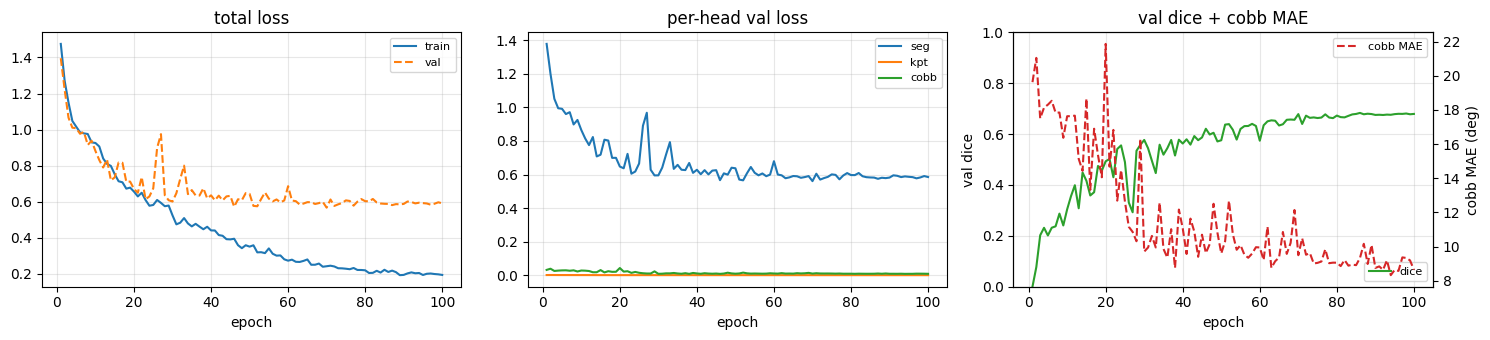

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

ax = axes[0]
ax.plot(history_df["epoch"], history_df["train_loss"], label="train", linewidth=1.5)
ax.plot(history_df["epoch"], history_df["val_loss"], label="val", linestyle="--")
ax.set_title("total loss"); ax.set_xlabel("epoch"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for k, color in [("val_seg", "tab:blue"), ("val_kpt", "tab:orange"), ("val_cobb", "tab:green")]:
    ax.plot(history_df["epoch"], history_df[k], label=k.replace("val_", ""), color=color)
ax.set_title("per-head val loss"); ax.set_xlabel("epoch"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(history_df["epoch"], history_df["val_dice"], color="tab:green", linewidth=1.5, label="dice")
ax.set_ylabel("val dice"); ax.set_xlabel("epoch"); ax.set_ylim(0, 1)
ax2 = ax.twinx()
ax2.plot(history_df["epoch"], history_df["val_cobb_mae"], color="tab:red", linestyle="--", label="cobb MAE")
ax2.set_ylabel("cobb MAE (deg)")
ax.set_title("val dice + cobb MAE"); ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.show()

## 7 · Evaluation — Three Cobb Estimators

The multi-task model exposes **three independent paths** to a Cobb angle for the same case:

1. **Direct** — `cobb_head` scalar output
2. **From keypoints** — argmax peaks of the keypoint heatmaps → endplate slopes → Cobb
3. **From segmentation** — `seg_head` argmax → existing `cobb_from_segmentation_tangent`

Compare against ground-truth `cobb_angle_deg` to see which path the multi-task encoder produces best, and whether ensembling all three helps.

In [16]:
def cobb_from_keypoints(coords_xy: np.ndarray, num_vert: int = NUM_VERT) -> float:
    """Brute-force pairwise endplate angle.

    coords_xy: (68, 2) float, NaN where keypoint missing. Order: TL, TR, BL, BR per vertebra.
    Returns max absolute difference (deg) between any two endplate slopes.
    """
    angles_top = []
    angles_bot = []
    indices = []
    for v in range(num_vert):
        tl, tr, bl, br = coords_xy[4 * v : 4 * v + 4]
        if np.isfinite(tl).all() and np.isfinite(tr).all():
            dy = tr[1] - tl[1]
            dx = tr[0] - tl[0]
            angles_top.append(math.degrees(math.atan2(dy, dx)))
        else:
            angles_top.append(np.nan)
        if np.isfinite(bl).all() and np.isfinite(br).all():
            dy = br[1] - bl[1]
            dx = br[0] - bl[0]
            angles_bot.append(math.degrees(math.atan2(dy, dx)))
        else:
            angles_bot.append(np.nan)
        indices.append(v)
    a = np.array(angles_top + angles_bot)
    a = a[np.isfinite(a)]
    if len(a) < 2:
        return float("nan")
    diffs = np.abs(a[:, None] - a[None, :])
    return float(diffs.max())


@torch.no_grad()
def evaluate_case(model: nn.Module, row: pd.Series) -> dict:
    case = preprocess_case(row)
    out = model(case["image"].unsqueeze(0).to(DEVICE))
    seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu()
    kpt_hm = out["kpt"].squeeze(0).cpu()
    cobb_direct = float(out["cobb"].squeeze(0).cpu())

    # dice (mean over present target classes)
    dice_scores: list[float] = []
    for c in range(1, NUM_SEG_CLASSES):
        p, g = (seg_pred == c), (case["seg"] == c)
        denom = p.sum() + g.sum()
        if denom > 0:
            dice_scores.append(float(2.0 * (p & g).sum() / denom))
    dice_mean = float(np.mean(dice_scores)) if dice_scores else float("nan")

    # Cobb from seg pipeline (existing)
    cobb_from_seg = float(cobb_from_segmentation_tangent(seg_pred.numpy()))
    # Cobb from keypoint heatmaps
    coords, _scores = keypoints_from_heatmaps(kpt_hm)
    cobb_from_kpt = cobb_from_keypoints(coords)

    out_row = {
        "dice": dice_mean,
        "cobb_direct": cobb_direct,
        "cobb_from_seg": cobb_from_seg,
        "cobb_from_kpt": cobb_from_kpt,
    }
    gt = row.get("cobb_angle_deg")
    if pd.notna(gt):
        gt = float(gt)
        out_row["cobb_true"] = gt
        for k in ["cobb_direct", "cobb_from_seg", "cobb_from_kpt"]:
            v = out_row[k]
            out_row[f"{k}_abs_err"] = abs(v - gt) if np.isfinite(v) else float("nan")
    return out_row

eval_rows = [evaluate_case(model, r) for _, r in VAL_DF.iterrows()]
eval_df = pd.DataFrame(eval_rows)
print(f"evaluated {len(eval_df)} val cases")
eval_df.head()

evaluated 50 val cases


,dice,cobb_direct,cobb_from_seg,cobb_from_kpt,cobb_true,cobb_direct_abs_err,cobb_from_seg_abs_err,cobb_from_kpt_abs_err
0,0.759524,77.837021,73.363447,48.406444,80.171357,2.334336,6.807911,31.764913
1,0.940017,38.879627,10.796946,22.696583,NaN,NaN,NaN,NaN
2,0.431883,90.319748,122.174994,48.366461,90.000000,0.319748,32.174994,41.633539
3,0.879161,28.548851,9.635565,28.474204,NaN,NaN,NaN,NaN
4,0.831470,37.134338,44.848890,53.673174,37.935438,0.801100,6.913452,15.737736


In [17]:
summary = {
    "n_val":             int(len(eval_df)),
    "mean_dice":         float(eval_df["dice"].mean()),
}
with_gt = eval_df.dropna(subset=["cobb_true"]) if "cobb_true" in eval_df else pd.DataFrame()
if len(with_gt):
    summary["n_with_cobb_gt"] = int(len(with_gt))
    for col in ["cobb_direct", "cobb_from_seg", "cobb_from_kpt"]:
        err = with_gt[f"{col}_abs_err"].dropna()
        if len(err):
            summary[f"{col}_mae"] = float(err.mean())
            summary[f"{col}_n"] = int(len(err))

print("=== Multi-Task v1 — single 80/20 split ===")
for k, v in summary.items():
    print(f"  {k:30s} {v}")
print(f"\nv3_corrected baseline (single split): val_dice ≈ 0.64")
print(f"v3_corrected pipeline floor:          ~10.4° MAE (seg from GT mask)")

=== Multi-Task v1 — single 80/20 split ===
  n_val                          50
  mean_dice                      0.6862332299280474
  n_with_cobb_gt                 32
  cobb_direct_mae                9.337744178821417
  cobb_direct_n                  32
  cobb_from_seg_mae              13.457145455452855
  cobb_from_seg_n                32
  cobb_from_kpt_mae              19.692625852621873
  cobb_from_kpt_n                32

v3_corrected baseline (single split): val_dice ≈ 0.64
v3_corrected pipeline floor:          ~10.4° MAE (seg from GT mask)


## 8 · Qualitative Check

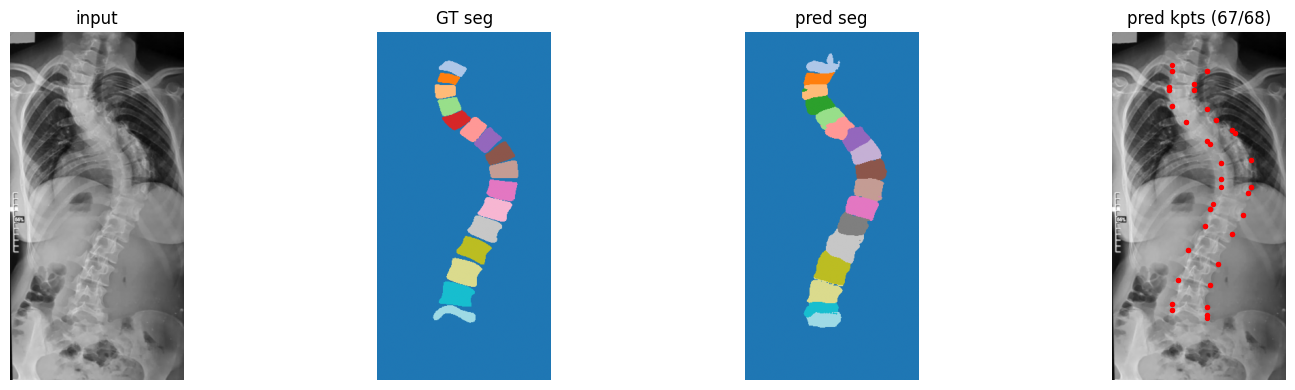

In [18]:
row = VAL_DF.iloc[0]
case = preprocess_case(row)
model.eval()
with torch.no_grad():
    out = model(case["image"].unsqueeze(0).to(DEVICE))
seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu()
kpt_hm = out["kpt"].squeeze(0).cpu()
coords, scores = keypoints_from_heatmaps(kpt_hm)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("input")
axes[1].imshow(case["seg"], cmap="tab20"); axes[1].set_title("GT seg")
axes[2].imshow(seg_pred, cmap="tab20"); axes[2].set_title("pred seg")
axes[3].imshow(case["image"].squeeze(0), cmap="gray")
fin = np.isfinite(coords).all(axis=1)
axes[3].scatter(coords[fin, 0], coords[fin, 1], s=8, c="red")
axes[3].set_title(f"pred kpts ({int(fin.sum())}/68)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 9 · Conclusions

Fill in after first run:

- **Mean val Dice vs v3_corrected baseline (~0.64):**
- **Cobb MAE: direct head vs derived-from-seg vs derived-from-kpt:**
- **Loss balance:** does training share gradients evenly, or does one head dominate? (`train_seg`/`train_kpt`/`train_cobb` curves)
- **Next steps:**
    - tune `LAMBDA_*` if one loss dominates
    - try uncertainty-weighted multi-task loss (Kendall et al.) to learn the balance
    - if direct Cobb beats derived: skip seg+kpt pipelines at inference
    - if derived-from-kpt beats derived-from-seg: arch #2 (pure keypoint) is the better pivot